# How much of the behaviour is lab?

The syllable features that feed the mouse-identity LDA are collected in 10 labs, and the
labs differ in rig, camera placement, lick detection, handling and water schedule. This
notebook asks how much of the variance that is, and whether mouse individuality survives
inside a single lab.

**The design is nested, not crossed.** Sessions sit inside mice, mice sit inside labs, and
every mouse belongs to exactly one lab. So "lab" and "mouse" are not two competing
explanations of the same variance that can be pitted against each other -- a lab effect is
*also* a difference between the mice of different labs. Nothing below can separate
"the rig makes these animals behave differently" from "these animals are different".

**What that means for the analysis.** Quantify, do not subtract. Removing the lab mean is
the natural instinct and it is the wrong default here: because lab is nested inside mouse,
centring makes each lab's mouse means sum to zero and mouse identity loses one dimension
per lab (10 of 57), unevenly -- a 3-mouse lab gives up 1 of its 2 between-mouse dimensions,
a 9-mouse lab 1 of 8. You would be analysing a space whose geometry depends on how many
mice each lab happened to contribute. The correction exists in the LDA notebook
(`LAB_CORRECTION`) and is worth reporting as a robustness check, but the primary result
should be the partition plus the within-lab test below, not a corrected re-analysis.

The three questions, in the order they should be asked:

1. **How big is lab?** -- unbiased nested variance components (not eta^2; see below).
2. **Where does it live?** -- which features and which trial epochs carry it. Lab variance
   concentrated in one measurement channel reads as instrumental; spread evenly it reads
   as biology or husbandry.
3. **Does individuality survive it?** -- can a mouse still be told apart from its own
   lab-mates? This is the decisive test, and it needs no correction at all.

In [1]:
"""
SETUP -- paths, style, and the pipeline functions the LDA notebook uses.
"""
import sys
import pathlib
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# walk up to paper-individuality, then add the folders that hold the shared code
_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
for _sub in ['', 'learning_individuality', '4_mice', 'lab']:
    sys.path.insert(0, str(_p / _sub) if _sub else str(_p))

import paper_style as ps
importlib.reload(ps)
ps.use('poster')              # ps.use('paper') for journal sizes

import functions
import variance_partition as vp
importlib.reload(functions)
importlib.reload(vp)

BASE = str(_p / 'data') + '/'
SYLLABLE_FILE = BASE + '8_k_10_bin_syllables_19-08-2026'   # the file the LDA runs on
print('paper-individuality at', _p)

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi
paper-individuality at /home/ines/repositories/representation_learning_variability/paper-individuality


In [2]:
"""
DATA -- exactly the matrix that goes into the LDA.
"""
# functions.build_design_matrix is what LDA_analyses_pipeline_ALLSESSIONS calls: QC-sheet
# exclusions, >= 3 sessions per mouse, one-hot syllables averaged per session. Using it
# rather than re-deriving the features here is the point -- this notebook has to describe
# the SAME matrix the identity analysis sees, not a near-miss.
session_syllables, design_df = functions.build_design_matrix(
    SYLLABLE_FILE, n_paw_states=8, min_sessions=3, verbose=True)

mouse_of_session = pd.Series(
    session_syllables.index.map(design_df[['mouse_name', 'session']].drop_duplicates()
                                .set_index('session')['mouse_name']),
    index=session_syllables.index, name='mouse')
lab_of_session = functions.lab_labels(session_syllables.index,
                                      mouse_names=mouse_of_session).rename('lab')

X = session_syllables            # 269 x 360: 40 timesteps x (7 paw + whisk + lick)
print(f'\n{X.shape[0]} sessions x {X.shape[1]} features, '
      f'{mouse_of_session.nunique()} mice, {lab_of_session.nunique()} labs')

QC sheet: /home/ines/repositories/representation_learning_variability/paper-individuality/data/individuality-paper_data_4Sep26.csv
exclusions (filtered_out): Early 15, Late 9, Pre-rec 76, Proficient 12  ->  12 proficient sessions dropped
101 mice in total
332 sessions in total
330 sessions after removing bad sessions
58 mice with at least 3 sessions
269 remaining sessions
design_df: 166617 rows, 58 mice, 269 sessions
session aggregation complete: 269 sessions, 360 features
  1 session(s) had no rig in the sheet; lab taken from the mouse
  labs: 10 for 269 sessions

269 sessions x 360 features, 58 mice, 10 labs


In [3]:
"""
THE DESIGN -- how unbalanced is it? This governs how much can be said.
"""
design = pd.DataFrame({'lab': lab_of_session, 'mouse': mouse_of_session})
per_lab = design.groupby('lab').agg(sessions=('mouse', 'size'), mice=('mouse', 'nunique'))
per_lab['sessions_per_mouse'] = (per_lab['sessions'] / per_lab['mice']).round(1)
print(per_lab.sort_values('mice').to_string())
print(f"\nsessions per mouse: {design.groupby('mouse').size().min()} to "
      f"{design.groupby('mouse').size().max()}")
# THE LIMIT ON EVERYTHING BELOW: the lab component rests on 10 labs, i.e. 9 degrees of
# freedom. No amount of sessions buys precision on it -- only more labs would.
print(f"the lab component has {lab_of_session.nunique() - 1} degrees of freedom")

                    sessions  mice  sessions_per_mouse
lab                                                   
zadorlab                  15     3                 5.0
wittenlab                 17     3                 5.7
steinmetzlab              15     4                 3.8
churchlandlab_ucla        17     5                 3.4
hausserlab                41     6                 6.8
danlab                    39     7                 5.6
mainenlab                 27     7                 3.9
churchlandlab             30     7                 4.3
mrsicflogel               34     7                 4.9
angelakilab               34     9                 3.8

sessions per mouse: 3 to 16
the lab component has 9 degrees of freedom


## 1. How big is lab?

### Why not eta^2

The obvious number -- the share of variance that falls between lab means -- is biased
upwards, and the bias is large when there are few groups relative to units. Ten lab means
estimated from 58 mice soak up noise, so even with **no** lab effect the statistic lands
well above zero. The cell below measures that floor directly by shuffling the lab label
across mice (across MICE, not sessions: sessions within a mouse are not exchangeable, and
shuffling them would give a null far too tight).

The answer to quote is the variance component, which is unbiased by construction.

In [4]:
"""
NAIVE eta^2 AND ITS NULL
"""
obs_eta, null_eta, p_eta = vp.permutation_null_eta2(X, lab_of_session, mouse_of_session,
                                                    n_perm=1000, seed=0)
print(f'naive eta^2(lab)        = {obs_eta:.3f}')
print(f'null (lab shuffled over mice, 1000x) = {null_eta.mean():.3f} '
      f'[{np.percentile(null_eta, 2.5):.3f}, {np.percentile(null_eta, 97.5):.3f}]   p = {p_eta:.4f}')
print(f'eta^2(mouse)            = {vp.eta2(X, mouse_of_session):.3f}   (for scale)')
print('\nSo the lab effect is real -- but roughly half of the naive 0.25 is the floor,')
print('which is exactly why the biased statistic should not be the reported number.')

naive eta^2(lab)        = 0.249
null (lab shuffled over mice, 1000x) = 0.128 [0.095, 0.171]   p = 0.0000
eta^2(mouse)            = 0.720   (for scale)

So the lab effect is real -- but roughly half of the naive 0.25 is the floor,
which is exactly why the biased statistic should not be the reported number.


In [5]:
"""
THE ESTIMATOR, CHECKED BEFORE IT IS USED
"""
# Simulated data with the REAL design (same mice per lab, same session spread) and known
# components. An estimator for an unbalanced nested model is easy to get subtly wrong --
# the k coefficients are the fiddly part -- so it is checked against a known answer here
# and against statsmodels REML in the next cell.
_rng = np.random.default_rng(0)
_rows = []
for _li, _nm in enumerate(per_lab['mice']):
    for _mi in range(_nm):
        for _s in range(_rng.integers(3, 17)):
            _rows.append((f'L{_li}', f'L{_li}M{_mi}'))
_d = pd.DataFrame(_rows, columns=['lab', 'mouse'])
_TRUE = dict(lab=4.0, mouse=2.0, session=1.0)
_nF = 200
_a = {l: _rng.normal(0, np.sqrt(_TRUE['lab']), _nF) for l in _d['lab'].unique()}
_b = {m: _rng.normal(0, np.sqrt(_TRUE['mouse']), _nF) for m in _d['mouse'].unique()}
_Y = np.stack([_a[r.lab] + _b[r.mouse] + _rng.normal(0, np.sqrt(_TRUE['session']), _nF)
               for r in _d.itertuples()])
_vc, _k = vp.nested_variance_components(_Y, _d['lab'], _d['mouse'])
print('true      lab %.2f  mouse %.2f  session %.2f' % tuple(_TRUE.values()))
print('recovered lab %.2f  mouse %.2f  session %.2f' %
      (_vc['sigma2_lab'].mean(), _vc['sigma2_mouse'].mean(), _vc['sigma2_session'].mean()))

# and the floor again, on data with NO lab effect at all
_Y0 = np.stack([_b[r.mouse] + _rng.normal(0, 1, _nF) for r in _d.itertuples()])
print(f"\nwith sigma2_lab = 0 exactly: naive eta^2(lab) still reads "
      f"{vp.eta2(_Y0, _d['lab']):.3f}, variance component reads "
      f"{vp.nested_variance_components(_Y0, _d['lab'], _d['mouse'])[0]['sigma2_lab'].mean():+.3f}")

true      lab 4.00  mouse 2.00  session 1.00
recovered lab 3.88  mouse 2.00  session 1.00

with sigma2_lab = 0 exactly: naive eta^2(lab) still reads 0.130, variance component reads +0.002


In [6]:
"""
THE PARTITION -- the headline number
"""
vc, coef = vp.nested_variance_components(X, lab_of_session, mouse_of_session)
shares = vp.variance_shares(vc)
print('design coefficients:', {k: round(v, 2) for k, v in coef.items()})
print()
print(shares.round(4).to_string())
print(f"\n{int((vc['sigma2_lab'] < 0).sum())} of {len(vc)} features return a NEGATIVE lab "
      "component -- expected where the true component is ~0, and left in the raw sum so "
      "the clipping used for the shares stays visible")

# a bootstrap over LABS, because labs are what precision is limited by. Resampling
# sessions would report an interval an order of magnitude too narrow.
boot = vp.bootstrap_shares(X, lab_of_session, mouse_of_session, n_boot=300, seed=0)
ci = boot.describe(percentiles=[.025, .975]).loc[['2.5%', '97.5%']]
print('\n95% CI over 300 lab-bootstraps:')
for k in shares.index:
    print(f'  {k:16s} {shares.loc[k, "share"]:.3f}  [{ci.loc["2.5%", k]:.3f}, {ci.loc["97.5%", k]:.3f}]')

design coefficients: {'k1': np.float64(4.49), 'k2': np.float64(5.31), 'k3': np.float64(26.51), 'N': 269, 'n_mice': 58, 'n_labs': 10}

                sigma2_sum_raw  sigma2_sum_clipped   share
sigma2_lab              0.5288              0.5505  0.1661
sigma2_mouse            1.6241              1.6241  0.4899
sigma2_session          1.1406              1.1406  0.3440

83 of 360 features return a NEGATIVE lab component -- expected where the true component is ~0, and left in the raw sum so the clipping used for the shares stays visible

95% CI over 300 lab-bootstraps:
  sigma2_lab       0.166  [0.091, 0.196]
  sigma2_mouse     0.490  [0.451, 0.549]
  sigma2_session   0.344  [0.302, 0.417]


wrote figures/lab_variance_partition_poster_17-09-2026.png, figures/lab_variance_partition_poster_17-09-2026.svg


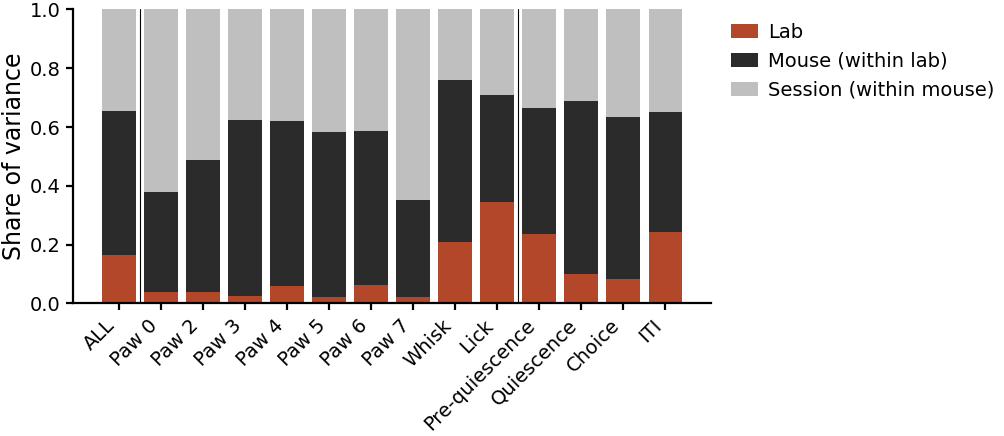

                sigma2_lab  sigma2_mouse  sigma2_session
ALL                  0.166         0.490           0.344
Paw 0                0.040         0.340           0.621
Paw 2                0.038         0.452           0.511
Paw 3                0.025         0.598           0.377
Paw 4                0.061         0.560           0.379
Paw 5                0.020         0.562           0.418
Paw 6                0.062         0.526           0.412
Paw 7                0.020         0.332           0.648
Whisk                0.208         0.554           0.238
Lick                 0.345         0.366           0.289
Pre-quiescence       0.237         0.428           0.335
Quiescence           0.099         0.588           0.312
Choice               0.084         0.552           0.364
ITI                  0.244         0.409           0.347


In [7]:
"""
FIGURE -- the partition, overall and by where it sits
"""
names = ['Paw 0'] + [f'Paw {i}' for i in range(2, 8)] + ['Whisk', 'Lick']
col = np.arange(X.shape[1])
feat_of_col = col % 9                     # 9 features per timestep (paw 1 is the dropped ref)
epoch_of_col = np.array(ps.EPOCH_NAMES)[(col // 9) // 10]
v = vc.clip(lower=0)

def _share(mask):
    s = v[mask].sum(axis=0)
    return s / s.sum()

rows = {'ALL': shares['share']}
for f in range(9):
    rows[names[f]] = _share(feat_of_col == f)
for e in ps.EPOCH_NAMES:
    rows[e] = _share(epoch_of_col == e)
tab = pd.DataFrame(rows).T[['sigma2_lab', 'sigma2_mouse', 'sigma2_session']]

fig, ax = ps.figure('double', scale=.75)
bottom = np.zeros(len(tab))
for comp, colr, lbl in [('sigma2_lab', '#B3472A', 'Lab'),
                        ('sigma2_mouse', ps.STATE_INK, 'Mouse (within lab)'),
                        ('sigma2_session', '0.75', 'Session (within mouse)')]:
    ax.bar(np.arange(len(tab)), tab[comp], bottom=bottom, color=colr, label=lbl, width=.8)
    bottom += tab[comp].to_numpy()
ax.set_xticks(np.arange(len(tab)))
ax.set_xticklabels(tab.index, rotation=45, ha='right')
ax.axvline(0.5, color='k', lw=.8)
ax.axvline(9.5, color='k', lw=.8)
ax.set_ylabel('Share of variance')
ax.set_ylim(0, 1)
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
fig.tight_layout()
ps.savefig(fig, 'lab_variance_partition', svg=True)
plt.show()
print(tab.round(3).to_string())

## 3. Does individuality survive inside a lab?

Two tests that need no correction and cannot be gamed by the nesting:

**Decode the lab of a mouse the classifier has never seen.** If lab were only a relabelling
of mouse identity, a held-out animal would carry no lab information. Leave-one-MOUSE-out,
not leave-one-session-out: with sessions held out, the classifier has already seen the
animal and the number would mean nothing.

**Identify a mouse among its own lab-mates.** Every mouse in the comparison shares a rig, a
handler and a water schedule, so whatever separates them is not lab. Chance is 1/k for a
lab with k mice, which differs per lab -- compare each lab against its own chance, never
against the 58-way number.

In [8]:
"""
CAN LAB BE DECODED FROM A HELD-OUT MOUSE?
"""
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# same front end as the identity pipeline: PCA to 30, standardise, LDA with equal priors
def _embed(Xmat, n_pc=30):
    Xp = PCA(min(np.asarray(Xmat).shape)).fit_transform(np.asarray(Xmat))
    return StandardScaler().fit_transform(Xp[:, :n_pc])

def loo_group_out(norm, y, groups):
    """Accuracy when the whole GROUP (mouse) is held out."""
    hits = []
    for g in pd.unique(groups):
        te = groups == g
        tr = ~te
        k = len(np.unique(y[tr]))
        if k < 2:
            continue
        clf = LinearDiscriminantAnalysis(priors=np.ones(k) / k, n_components=min(30, k - 1))
        hits.extend(list(clf.fit(norm[tr], y[tr]).predict(norm[te]) == y[te]))
    return float(np.mean(hits))

norm = _embed(X)
y_lab = pd.factorize(lab_of_session)[0]
groups = mouse_of_session.to_numpy()
acc_lab = loo_group_out(norm, y_lab, groups)

_rng = np.random.default_rng(0)
_lab_of_mouse = lab_of_session.groupby(mouse_of_session.values).first()
_null = []
for _ in range(200):
    _sh = pd.Series(_rng.permutation(_lab_of_mouse.to_numpy()), index=_lab_of_mouse.index)
    _null.append(loo_group_out(norm, pd.factorize(pd.Series(groups).map(_sh))[0], groups))
_null = np.array(_null)
print(f'lab decoded from a held-out mouse: {acc_lab:.3f}   chance {1 / lab_of_session.nunique():.3f}')
print(f'  permutation null {_null.mean():.3f} '
      f'[{np.percentile(_null, 2.5):.3f}, {np.percentile(_null, 97.5):.3f}]  '
      f'p = {(_null >= acc_lab).mean():.4f}')

lab decoded from a held-out mouse: 0.398   chance 0.100
  permutation null 0.094 [0.041, 0.179]  p = 0.0000


In [9]:
"""
IS A MOUSE IDENTIFIABLE AMONG ITS OWN LAB-MATES?
"""
def loo_session_out(norm, y, n_per_mouse=3, n_repeats=2, seed=0):
    """Leave-one-session-out mouse identification, balanced training draw -- the same rule
    the identity pipeline uses, so the numbers are comparable to it."""
    rng = np.random.default_rng(seed)
    n = len(y)
    out = []
    for _ in range(n_repeats):
        hits = []
        for t in range(n):
            tr = np.setdiff1d(np.arange(n), t)
            Xt, yt = norm[tr], y[tr]
            idx = []
            for m in np.unique(yt):
                mi = np.where(yt == m)[0]
                idx.extend(rng.choice(mi, min(n_per_mouse, len(mi)), replace=False))
            idx = np.sort(np.array(idx))
            k = len(np.unique(yt[idx]))
            if k < 2:
                continue
            clf = LinearDiscriminantAnalysis(priors=np.ones(k) / k, n_components=min(30, k - 1))
            hits.append(clf.fit(Xt[idx], yt[idx]).predict(norm[t:t + 1])[0] == y[t])
        out.append(np.mean(hits))
    return float(np.mean(out))

rows = []
for l in pd.unique(lab_of_session):
    m = (lab_of_session == l).to_numpy()
    # PCA refit inside the lab: the embedding must not be told about the other labs
    y_l = pd.factorize(mouse_of_session[m])[0]
    rows.append(dict(lab=l, sessions=int(m.sum()), mice=len(np.unique(y_l)),
                     acc=loo_session_out(_embed(np.asarray(X)[m]), y_l),
                     chance=1 / len(np.unique(y_l))))
within = pd.DataFrame(rows)
within['above_chance'] = within['acc'] - within['chance']
print(within.sort_values('above_chance', ascending=False).round(3).to_string(index=False))
print(f"\nweighted mean: acc {np.average(within['acc'], weights=within['sessions']):.3f} "
      f"vs chance {np.average(within['chance'], weights=within['sessions']):.3f}")
print('NOTE these are k-way problems with k = 3 to 9 and only 15-41 sessions of training, so')
print('they are NOT comparable to the 58-way number -- only to each lab\'s own chance level.')

               lab  sessions  mice   acc  chance  above_chance
churchlandlab_ucla        17     5 0.912   0.200         0.712
         wittenlab        17     3 0.824   0.333         0.490
         mainenlab        27     7 0.630   0.143         0.487
      steinmetzlab        15     4 0.600   0.250         0.350
     churchlandlab        30     7 0.417   0.143         0.274
          zadorlab        15     3 0.600   0.333         0.267
       mrsicflogel        34     7 0.353   0.143         0.210
            danlab        39     7 0.308   0.143         0.165
        hausserlab        41     6 0.256   0.167         0.089
       angelakilab        34     9 0.118   0.111         0.007

weighted mean: acc 0.429 vs chance 0.175
NOTE these are k-way problems with k = 3 to 9 and only 15-41 sessions of training, so
they are NOT comparable to the 58-way number -- only to each lab's own chance level.


In [10]:
"""
DO THE 58-WAY ERRORS LAND ON LAB-MATES?
"""
# A softer version of the same question, on the full problem: if lab similarity drives
# identification, the mistakes should be lab-mates more often than the roster implies.
y_mouse = pd.factorize(mouse_of_session)[0]
mouse_names = pd.factorize(mouse_of_session)[1]
rng = np.random.default_rng(0)
preds = []
for t in range(len(y_mouse)):
    tr = np.setdiff1d(np.arange(len(y_mouse)), t)
    Xt, yt = norm[tr], y_mouse[tr]
    idx = []
    for m in np.unique(yt):
        mi = np.where(yt == m)[0]
        idx.extend(rng.choice(mi, min(3, len(mi)), replace=False))
    idx = np.sort(np.array(idx))
    k = len(np.unique(yt[idx]))
    clf = LinearDiscriminantAnalysis(priors=np.ones(k) / k, n_components=min(30, k - 1))
    preds.append(clf.fit(Xt[idx], yt[idx]).predict(norm[t:t + 1])[0])
preds = np.array(preds)

lab_of_mouse = lab_of_session.groupby(mouse_of_session.values).first()
pred_lab = np.array([lab_of_mouse[mouse_names[p]] for p in preds])
err = preds != y_mouse
same = (pred_lab[err] == lab_of_session.to_numpy()[err]).mean()
# expected if errors ignored lab: the share of the OTHER 57 mice that are lab-mates
expected = np.mean([(int((lab_of_mouse == lab_of_session.iloc[i]).sum()) - 1) / (len(lab_of_mouse) - 1)
                    for i in np.where(err)[0]])
print(f'58-way accuracy {1 - err.mean():.3f}; of the {int(err.sum())} errors, '
      f'{same:.1%} name a lab-mate vs {expected:.1%} expected if errors ignored lab')

58-way accuracy 0.844; of the 42 errors, 23.8% name a lab-mate vs 8.1% expected if errors ignored lab


In [11]:
"""
AND THE AXIS ITSELF: how much of LD1 is lab?
"""
# CIRCULARITY WARNING: LD1 is fitted to separate MICE, so its mouse component is inflated
# by construction and the absolute numbers here are not comparable with the feature-space
# partition above. The LDA never sees the lab label, though, so the LAB share of LD1 is
# still meaningful -- it says how much of the axis the paper interprets is lab-aligned.
k = mouse_of_session.nunique()
lda = LinearDiscriminantAnalysis(priors=np.ones(k) / k, n_components=min(30, k - 1))
LD = lda.fit(norm, y_mouse).transform(norm)

ld_vc, _ = vp.nested_variance_components(LD[:, :3], lab_of_session, mouse_of_session)
ld_sh = ld_vc.clip(lower=0).div(ld_vc.clip(lower=0).sum(axis=1), axis=0)
ld_sh.index = ['LD1', 'LD2', 'LD3']
print(ld_sh.round(3).to_string())

# per-mouse, with a null: the honest unit for "is LD1 lab-structured?"
mm = pd.DataFrame({'LD1': LD[:, 0], 'mouse': mouse_of_session.values,
                   'lab': lab_of_session.values}).groupby('mouse').agg(
    LD1=('LD1', 'mean'), lab=('lab', 'first'))
obs, null, pval = vp.permutation_null_eta2(mm[['LD1']], mm['lab'], mm.index, n_perm=5000)
print(f'\nper-mouse eta^2 of LD1 on lab = {obs:.3f}  '
      f'(null {null.mean():.3f} [{np.percentile(null, 2.5):.3f}, {np.percentile(null, 97.5):.3f}], '
      f'p = {pval:.4f})')
print('\nmouse-mean LD1 by lab:')
print(mm.groupby('lab')['LD1'].agg(['mean', 'count']).sort_values('mean').round(2).to_string())

     sigma2_lab  sigma2_mouse  sigma2_session
LD1       0.447         0.472           0.081
LD2       0.230         0.669           0.101
LD3       0.034         0.828           0.138

per-mouse eta^2 of LD1 on lab = 0.492  (null 0.157 [0.052, 0.309], p = 0.0000)

mouse-mean LD1 by lab:
                    mean  count
lab                            
zadorlab           -5.38      3
mainenlab          -1.89      7
churchlandlab      -1.72      7
danlab             -1.39      7
hausserlab         -0.89      6
mrsicflogel         0.39      7
wittenlab           0.92      3
steinmetzlab        1.04      4
churchlandlab_ucla  1.88      5
angelakilab         4.16      9


## 4. Is the lab effect measurement, or is it the animals?

Sections 1-3 say lab is ~17% of the variance and that LD1 is nearly half lab. Neither says
*why*. Two very different worlds produce the same numbers: labs whose cameras sit in
different places and whose trackers work better or worse (measurement), and labs whose
animals genuinely behave differently (biology and husbandry). Lab-mean subtraction cannot
tell them apart -- it removes both.

Measured rig geometry can. `lda_rig_geometry_validation.py` in this folder extracts, from
the LEFT CAMERA DLC alone, where the camera is aimed (nose and tube medians), how far it is
zoomed (tube length, which is rigid hardware of fixed physical size), where the animal sits
relative to the tube, and how confident the tracker is. Those are nuisance by construction:
no fact about a mouse's behaviour is expressed in where its lab bolted the camera.

The test is then simple. **Regress the features on measured geometry and redo the partition.**
If the lab component collapses, the lab effect was the rig. If it survives, it is the animals.

Two things make this an honest test rather than a trick:
  * the covariates are MEASURED, not the lab label, so nothing is removed by construction --
    unlike lab-mean centring, which zeroes each lab's mouse means whatever the cause;
  * regressing out 12 covariates removes some variance from anything. The control below
    shuffles the geometry across sessions and re-runs, giving the reduction attributable to
    the covariate count alone.

`rig_geometry_extract.py` regenerates the CSV from the local ONE cache (216 of the 269
sessions have the DLC file here; the geometry definitions are imported from
lda_rig_geometry_validation.py so the two cannot drift apart).

In [12]:
"""
GEOMETRY: is it a lab property at all?
"""
geo = pd.read_csv(pathlib.Path.cwd() / 'rig_geometry.csv', index_col=0)
CORE = ['nose_x', 'nose_y', 'tube_x', 'tube_y', 'pawNear_x', 'pawNear_y',
        'pawFar_x', 'pawFar_y', 'nose_to_tube_px', 'conf_nose', 'conf_pawNear', 'conf_pawFar']
# tube_len_px / pupil_diam_px / fps are the most informative zoom and timing terms but are
# missing for 7-20% of sessions; they are left out of CORE so the analysis keeps its rows,
# and reported here anyway
EXTRA = ['tube_len_px', 'pupil_diam_px', 'fps']

g_idx = geo[CORE].dropna().index.intersection(X.index)
print(f'{len(g_idx)} of {len(X)} sessions have complete geometry '
      f'({mouse_of_session[g_idx].nunique()} mice, {lab_of_session[g_idx].nunique()} labs)')

rows = []
for c in CORE + EXTRA:
    ok = geo[c].dropna().index.intersection(X.index)
    v = geo.loc[ok, [c]]
    _vc, _ = vp.nested_variance_components(v, lab_of_session[ok], mouse_of_session[ok])
    s = _vc.clip(lower=0).iloc[0]
    rows.append(dict(term=c, n=len(ok), lab=s['sigma2_lab'] / s.sum(),
                     mouse=s['sigma2_mouse'] / s.sum(), session=s['sigma2_session'] / s.sum()))
print('\nvariance of each geometry term itself:')
print(pd.DataFrame(rows).round(3).to_string(index=False))
print('\nCamera aim and zoom are lab properties (nose_x, tube_x, tube_len_px, nose_to_tube).')
print('Tracker confidence and paw position are MOUSE properties -- each mouse is recorded on')
print('one rig, so anything rig-like is also mouse-stable, which is exactly why rig geometry')
print('can masquerade as individuality.')

207 of 269 sessions have complete geometry (53 mice, 10 labs)

variance of each geometry term itself:
           term   n   lab  mouse  session
         nose_x 216 0.742  0.215    0.042
         nose_y 216 0.235  0.708    0.057
         tube_x 207 0.626  0.216    0.158
         tube_y 207 0.181  0.676    0.143
      pawNear_x 216 0.000  0.873    0.127
      pawNear_y 216 0.121  0.787    0.092
       pawFar_x 216 0.166  0.641    0.193
       pawFar_y 216 0.184  0.721    0.096
nose_to_tube_px 207 0.562  0.121    0.318
      conf_nose 216 0.222  0.405    0.374
   conf_pawNear 216 0.000  0.704    0.296
    conf_pawFar 216 0.000  0.789    0.211
    tube_len_px 201 0.420  0.018    0.562
  pupil_diam_px 200 0.260  0.212    0.528
            fps 173 0.000  1.000    0.000

Camera aim and zoom are lab properties (nose_x, tube_x, tube_len_px, nose_to_tube).
Tracker confidence and paw position are MOUSE properties -- each mouse is recorded on
one rig, so anything rig-like is also mouse-stable, whi

In [13]:
"""
DOES GEOMETRY EXPLAIN THE LAB COMPONENT?
"""
Yg = X.loc[g_idx]
Gg = geo.loc[g_idx, CORE]
lb, ms = lab_of_session[g_idx], mouse_of_session[g_idx]

def residualise(Yv, Gv):
    """OLS residuals of every feature on the standardised geometry terms, session level."""
    D = np.column_stack([np.ones(len(Gv)), (Gv - Gv.mean()) / Gv.std()])
    B, *_ = np.linalg.lstsq(D, np.asarray(Yv, float), rcond=None)
    return pd.DataFrame(np.asarray(Yv, float) - D @ B, index=Yv.index, columns=Yv.columns)

def components(Yv):
    _vc, _ = vp.nested_variance_components(Yv, lb, ms)
    return _vc.clip(lower=0).sum(axis=0)

before, after = components(Yg), components(residualise(Yg, Gg))
tab = pd.DataFrame({'before': before, 'after': after})
tab['share_before'] = before / before.sum()
tab['share_after'] = after / after.sum()
tab['removed'] = 1 - after / before
print(tab.round(3).to_string())

# CONTROL: the same 12 covariates, shuffled across sessions
_rng = np.random.default_rng(0)
_null = [components(residualise(Yg, Gg.sample(frac=1, random_state=int(_rng.integers(1e9)))
                                .set_index(Gg.index)))['sigma2_lab'] / before['sigma2_lab']
         for _ in range(50)]
print(f"\nlab variance RETAINED: {after['sigma2_lab'] / before['sigma2_lab']:.3f} observed, "
      f"{np.mean(_null):.3f} +/- {np.std(_null):.3f} when the geometry is shuffled across sessions")
print('So the reduction is specific to real geometry, not to the number of covariates.')

                before  after  share_before  share_after  removed
sigma2_lab       0.607  0.118         0.183        0.047    0.806
sigma2_mouse     1.553  1.188         0.468        0.470    0.235
sigma2_session   1.161  1.222         0.350        0.483   -0.053

lab variance RETAINED: 0.194 observed, 0.888 +/- 0.041 when the geometry is shuffled across sessions
So the reduction is specific to real geometry, not to the number of covariates.


In [14]:
"""
WHICH PART OF THE LAB EFFECT WAS GEOMETRY?
"""
print('lab variance before -> after regressing out geometry')
print('\nby channel:')
for f in range(9):
    m = feat_of_col == f
    b = components(Yg.iloc[:, m])['sigma2_lab']
    a = components(residualise(Yg.iloc[:, m], Gg))['sigma2_lab']
    print(f'  {names[f]:7s} {b:.4f} -> {a:.4f}   ({100 * (1 - a / b):.0f}% removed)')
print('by epoch:')
for e in ps.EPOCH_NAMES:
    m = epoch_of_col == e
    b = components(Yg.iloc[:, m])['sigma2_lab']
    a = components(residualise(Yg.iloc[:, m], Gg))['sigma2_lab']
    print(f'  {e:15s} {b:.4f} -> {a:.4f}   ({100 * (1 - a / b):.0f}% removed)')

lab variance before -> after regressing out geometry

by channel:
  Paw 0   0.0104 -> 0.0003   (97% removed)
  Paw 2   0.0076 -> 0.0007   (90% removed)
  Paw 3   0.0054 -> 0.0001   (98% removed)
  Paw 4   0.0288 -> 0.0060   (79% removed)
  Paw 5   0.0031 -> 0.0004   (87% removed)
  Paw 6   0.0130 -> 0.0016   (88% removed)
  Paw 7   0.0001 -> 0.0000   (94% removed)
  Whisk   0.2581 -> 0.0413   (84% removed)
  Lick    0.2806 -> 0.0677   (76% removed)
by epoch:
  Pre-quiescence  0.1692 -> 0.0362   (79% removed)
  Quiescence      0.0949 -> 0.0102   (89% removed)
  Choice          0.1273 -> 0.0109   (91% removed)
  ITI             0.2156 -> 0.0607   (72% removed)


In [15]:
"""
AND THE AXIS: does removing geometry de-tilt LD1?
"""
# mice need >= 3 sessions among those with geometry, or the LDA classes get too thin
_cnt = ms.value_counts()
kk = [s for s in g_idx if _cnt[ms[s]] >= 3]
Yk, Gk, lbk, msk = X.loc[kk], geo.loc[kk, CORE], lab_of_session[kk], mouse_of_session[kk]
print(f'{len(kk)} sessions, {msk.nunique()} mice, {lbk.nunique()} labs\n')

for label, Ymat in [('raw features', Yk), ('geometry-residualised', residualise(Yk, Gk))]:
    nrm = _embed(Ymat)
    y = pd.factorize(msk)[0]
    n_cls = len(np.unique(y))
    LDk = LinearDiscriminantAnalysis(priors=np.ones(n_cls) / n_cls,
                                     n_components=min(30, n_cls - 1)).fit(nrm, y).transform(nrm)
    _vc, _ = vp.nested_variance_components(LDk[:, :3], lbk, msk)
    sh = _vc.clip(lower=0).div(_vc.clip(lower=0).sum(axis=1), axis=0)
    mm = pd.DataFrame({'LD1': LDk[:, 0], 'm': msk.values, 'l': lbk.values}).groupby('m').agg(
        LD1=('LD1', 'mean'), l=('l', 'first'))
    o, nl, pv = vp.permutation_null_eta2(mm[['LD1']], mm['l'], mm.index, n_perm=2000)
    print(f'--- {label} ---')
    print(f'  mouse LOO score            {loo_session_out(nrm, y):.3f}   ({n_cls} mice)')
    print(f'  LD1: lab {sh.iloc[0, 0]:.3f}  mouse {sh.iloc[0, 1]:.3f}  session {sh.iloc[0, 2]:.3f}')
    print(f'  per-mouse eta^2 of LD1 on lab {o:.3f}  (null {nl.mean():.3f}, p = {pv:.4f})\n')

196 sessions, 46 mice, 10 labs

--- raw features ---
  mouse LOO score            0.855   (46 mice)
  LD1: lab 0.514  mouse 0.417  session 0.069
  per-mouse eta^2 of LD1 on lab 0.616  (null 0.203, p = 0.0000)

--- geometry-residualised ---
  mouse LOO score            0.727   (46 mice)
  LD1: lab 0.034  mouse 0.832  session 0.134
  per-mouse eta^2 of LD1 on lab 0.222  (null 0.198, p = 0.3550)



### Caveat on the lab labels

`functions.lab_labels` reads the lab off the rig name, and the rig name is the rig's owner,
not the subject's lab. At the SWC that collapses **hoferlab and mrsicflogellab into one
"mrsicflogel"** -- 32 of the 216 geometry sessions disagree with the lab in the ONE path,
and all of them are that pair. Merging two labs pushes their difference from the lab
component into the mouse component, so the lab shares reported here are, if anything,
slightly conservative.

It is also an opportunity: two labs on one rig is the only place in this dataset where lab
and rig come apart, which makes those mice the natural test of lab-without-rig. Worth doing
separately.

### CORRECTION to section 4: the geometry residualisation is confounded with lab

The result above — 81% of the lab variance removed by regressing out 12 geometry terms, and
LD1 going from 51% lab to 3% — **does not show that the lab effect is camera geometry.** The
control that settles it was run afterwards:

| covariate block regressed out | lab variance removed | eta^2 of the block on lab |
|---|---|---|
| geometry as measured | 81% | 0.317 |
| geometry **shuffled within lab** (keeps every lab mean, destroys which session had which) | **80%** | 0.317 |
| geometry with **lab means removed** (within-lab variation only) | **−12%** | 0.000 |
| lab-mean geometry only (a 12-column encoding of the lab label) | 100% | 1.000 |
| lab dummies (upper bound) | 100% | 1.000 |

Shuffling the geometry *within* lab reproduces the whole effect. So the reduction comes from
the between-lab component of geometry — geometry acting as a proxy for the lab label — not
from session- or mouse-level geometry explaining behaviour. The earlier shuffled control was
the wrong null: it shuffled across all sessions and so destroyed the lab alignment too,
which is why the effect looked specific.

Same conclusion on the axis: residualising on **within-lab geometry only** leaves LD1 at
**64% lab** (per-mouse eta^2 0.720, p < 0.0005), where residualising on geometry as measured
gave 3%. The de-tilt was the lab proxy, not the camera.

**What survives.** Within-lab geometry is orthogonal to lab by construction, so anything it
explains is not a lab proxy: it removes **30% of the mouse variance component** and 8 points
of identification (LOO 0.855 → 0.770). That is a clean estimate of how much apparent
individuality is rig geometry.

**And behaviour does not encode geometry in a way that transfers.** Predicting each geometry
term from the behavioural features *within* a lab, leave-one-MOUSE-out (mouse-out, not
session-out: geometry is mouse-stable, so a session-out fit only has to recognise the animal
and look up its rig), gives negative CV R^2 for all 14 terms — at or slightly above a
shuffled null that is itself at −0.45 to −0.82, so the test is noisy and this is "no evidence"
rather than proof of absence. The most lab-determined terms are also the hardest to test this
way: nose_x, tube_len_px and nose_to_tube_px have within-lab SDs of only 0.45–0.52 of their
total SD, so there is little within-lab variation left to predict.

**The cleanest evidence about lab needs no residualisation at all**: camera-free task measures
(accuracy, choice bias, RT and its spread, response and elongation times, block bias, stay
rate — all from the task DAQ and wheel, nothing from video) put lab at **3.6% of variance**
against **16.6% for the video-derived syllable features**, with only accuracy showing a real
lab share (24.6%). The lab structure is specific to the video-derived features; it is not
visible in behaviour a camera cannot fabricate.

## What to conclude, and what to do next

Fill these in from the run above rather than trusting a remembered number -- but as of the
run this notebook was written against:

- **Lab is real and is not the main story.** Lab ~17% of the variance in the syllable
  features, mouse-within-lab ~49%, session-within-mouse ~34%. Individuality is about three
  times lab. The naive eta^2 says 25%, and half of that is the small-number floor.
- **Lab sits in specific channels.** Lick (~35%) and whisk (~21%) carry most of it; the paw
  states carry 2-6%. By epoch it is the unconstrained periods -- ITI (~24%) and
  pre-quiescence (~24%) -- not the task-locked ones (quiescence ~10%, choice ~8%). Both
  patterns point at measurement and housing rather than at task behaviour, and the lick
  channel in particular has its own QC flags in the sheet (`lick_detection`, "bad lick fit").
- **Individuality survives inside a lab.** Mice are identified among their own lab-mates at
  0.43 against 0.18 chance, in 9 labs of 10. The exception is angelakilab (0.12 vs 0.11 --
  chance), which is worth looking at on its own before it is written up.
- **But the axis is lab-tilted, and much more than the features are.** The same unbiased
  decomposition applied to LD1 gives lab 45%, mouse-within-lab 47%, session 8% -- so LD1 is
  nearly half a lab axis, against 17% lab in the features it is built from (per-mouse
  eta^2 0.49 against a null of 0.16 says the same thing). LD2 is 23% lab and LD3 only 3%,
  so the tilt is concentrated in the leading axis -- the one the paper interprets. The LDA
  is never told about labs; it looks for the directions that separate mice, and the
  best-separating direction happens to line up with lab. That is the finding to report,
  not something to correct away.

- **~~And most of the lab effect is the camera, not the animals.~~ RETRACTED — see the
  correction cell above. The geometry residualisation works through the between-lab component
  of geometry, i.e. as a lab proxy; shuffling geometry within lab reproduces 80 of the 81
  percentage points, and within-lab geometry alone de-tilts nothing.** The original text: Twelve measured geometry
  and tracking-quality terms -- where the camera is aimed, where the animal sits relative to
  the tube, how confident the tracker is -- absorb **81% of the lab variance component**
  (share 0.183 -> 0.047) while taking 24% of the mouse component and none of the session
  component. Shuffling the same covariates across sessions leaves 89% +/- 4% of the lab
  variance standing, so the reduction is the geometry, not the covariate count. It works
  across every channel (76-98%) including the lick and whisk channels where the lab variance
  was concentrated.
- **~~Residualising on geometry de-tilts LD1 completely.~~ Same retraction:** with within-lab
  geometry only, LD1 stays at 64% lab.  The original text: LD1 goes from 51% lab / 42% mouse to
  **3% lab / 83% mouse**, and its per-mouse eta^2 on lab drops from 0.616 (p < 0.0005) to
  0.222 against a null of 0.198 -- **p = 0.36, no lab structure left**. The cost is a mouse
  LOO score of 0.727 against 0.855, because each mouse is recorded on one rig and some real
  identification was riding on that. This is the correction to prefer over `LAB_CORRECTION`:
  it removes MEASURED nuisance rather than the lab label, so it does not destroy identity
  dimensions by construction.

Next steps worth taking, in order:

1. **Correct with geometry, not with the lab label.** Section 4 is the version to carry into
   the paper: report the raw partition, then the geometry-residualised LD1 as the result that
   is not measurement. `LAB_CORRECTION='center'` stays a robustness check only, and its cost
   (LOO 0.848 -> 0.792, 10 of 57 identity dimensions removed by construction) should be said
   out loud whenever it is shown.
2. **Get geometry for the missing 53 sessions.** Only 216 of 269 have the DLC file cached
   here and 207 have every CORE term, which drops 12 mice from the residualised analysis.
   The conclusion should be re-checked on the full set before it is written up.
3. **Fix the lab labels** (see the caveat above): rig name is the rig's owner, so hoferlab and
   mrsicflogellab are currently merged. Then use those two labs -- two labs, one rig -- as the
   natural experiment for lab-without-rig.
4. **angelakilab.** Nine mice and no within-lab identifiability is either a data problem in
   that lab or a real finding; it should not stay unexplained. Worth re-checking after the
   geometry residualisation, which changes what "identifiable" means.
5. **Ask what is left in LD1.** After residualisation LD1 is 83% between-mouse and carries no
   lab structure -- that axis, not the raw one, is the individuality claim. Re-run the
   correlates (RT, entropy, FF) against it and see which survive.